# Assignment 2: Quantum Phase Estimation — Simulator-Only Version

**Parameters:** θ = 0.5, t = 5

This notebook contains only:
1. The Qiskit code actually run
2. A circuit image generated with `.draw('mpl')`
3. A measurement histogram generated with `plot_histogram(...)`
4. Calculations deriving θ from the histogram data

This version uses a noiseless simulator. It is useful as the baseline condition for the research study because ChatGPT can usually predict this result accurately.

In [ ]:
!pip install qiskit qiskit-aer matplotlib pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.0 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=8968f5d2e7b94164540d4f74a962501cd259d3e789507c2d9c7a9bc9bdcc56f7
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
# Install if needed in a fresh environment:
# !pip install qiskit qiskit-aer matplotlib pylatexenc

import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

/tmp/ipykernel_4984/115058013.py:25: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  iqft = QFT(num_qubits=t, inverse=True, do_swaps=True).decompose()


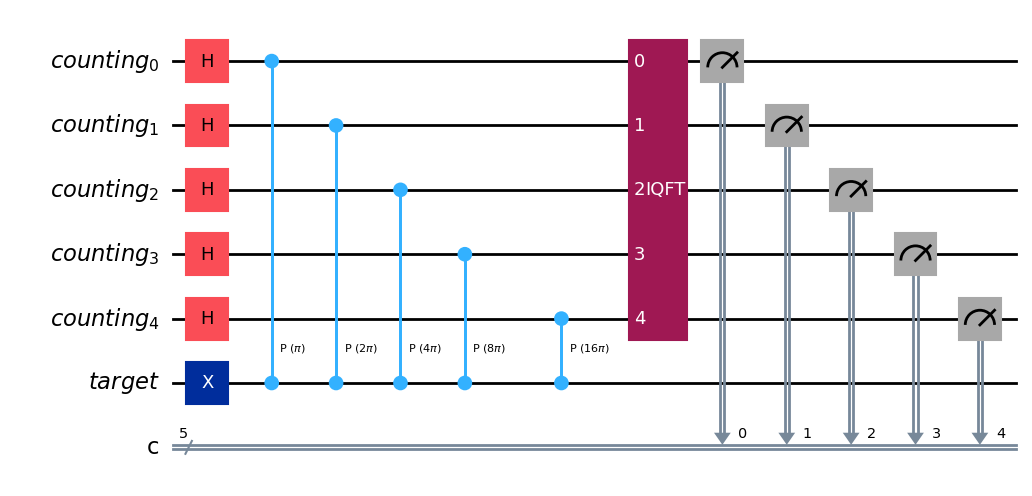

In [ ]:
# Assignment parameters
theta = 0.5
t = 5
shots = 1024

# Registers: t counting qubits + 1 eigenstate qubit
counting = QuantumRegister(t, "counting")
target = QuantumRegister(1, "target")
c = ClassicalRegister(t, "c")
qc = QuantumCircuit(counting, target, c)

# Prepare eigenstate |1> for the phase gate U = P(2*pi*theta)
qc.x(target[0])

# Put counting register into superposition
for q in counting:
    qc.h(q)

# Controlled-U^(2^j), where U|1> = exp(2*pi*i*theta)|1>
for j in range(t):
    angle = 2 * np.pi * theta * (2 ** j)
    qc.cp(angle, counting[j], target[0])

# Inverse QFT on the counting register
iqft = QFT(num_qubits=t, inverse=True, do_swaps=True).decompose()
qc.append(iqft, counting)

# Measure counting register
qc.measure(counting, c)

qc.draw("mpl")

Counts: {'10000': 1024}


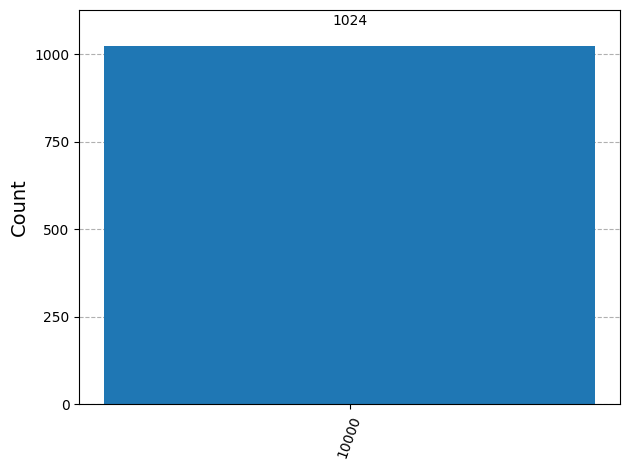

In [ ]:
# Run on noiseless simulator
simulator = AerSimulator()
compiled = transpile(qc, simulator)
job = simulator.run(compiled, shots=shots)
result = job.result()
counts = result.get_counts()

print("Counts:", counts)
plot_histogram(counts)

In [ ]:
# Derive theta from the histogram data

# Qiskit count keys are bitstrings. For this circuit, the expected dominant bitstring is 10000.
measured_bitstring = max(counts, key=counts.get)
measured_integer = int(measured_bitstring, 2)
theta_estimate = measured_integer / (2 ** t)

print(f"Most frequent measurement: {measured_bitstring}")
print(f"Measured integer: {measured_integer}")
print(f"theta = {measured_integer} / 2^{t} = {measured_integer} / {2 ** t} = {theta_estimate}")

Most frequent measurement: 10000
Measured integer: 16
theta = 16 / 2^5 = 16 / 32 = 0.5


## Calculation

With t = 5 counting qubits, there are 2^5 = 32 possible integer outcomes.

For θ = 0.5:

θ × 2^t = 0.5 × 32 = 16

16 in 5-bit binary is:

10000

Therefore, the expected dominant measurement is **10000**.

From the histogram, choose the most frequent bitstring and convert it to an integer m:

m = int(bitstring, 2)

Then:

θ estimate = m / 2^t

If the measured bitstring is 10000:

m = 16

θ = 16 / 32 = 0.5